In [88]:
import pandas as pd
df = pd.read_csv('../data/raw/train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [89]:
df['Name'].sample(15)

348               Coutts, Master. William Loch "William"
526                                 Ridsdale, Miss. Lucy
163                                      Calic, Mr. Jovo
781            Dick, Mrs. Albert Adrian (Vera Gillespie)
699             Humblen, Mr. Adolf Mathias Nicolai Olsen
220                       Sunderland, Mr. Victor Francis
478                            Karlsson, Mr. Nils August
652                       Kalvik, Mr. Johannes Halvorsen
701                     Silverthorne, Mr. Spencer Victor
518    Angle, Mrs. William A (Florence "Mary" Agnes H...
389                                Lehmann, Miss. Bertha
758                         Theobald, Mr. Thomas Leonard
619                                  Gavey, Mr. Lawrence
735                                 Williams, Mr. Leslie
219                                   Harris, Mr. Walter
Name: Name, dtype: str

In [90]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

print(f"\nUnvanı bulunamayan kişi sayısı: {titles.isnull().sum()}")

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

Unvanı bulunamayan kişi sayısı: 0


In [91]:
df['Title'] = df['Title'].replace('Mlle','Miss')
df['Title'] = df['Title'].replace('Ms','Miss')
df['Title'] = df['Title'].replace('Mme','Mrs')
df['Title'] = df['Title'].replace(['Countess','Jonkheer','Don','Dr','Rev','Lady','Major','Sir','Col','Capt'], 'Rare')
print(df['Title'].value_counts())


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [92]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

In [93]:
null_ages = df[df['Age'].isnull()].groupby('Title')['Age'].size()
print(null_ages)

Title
Master      4
Miss       36
Mr        119
Mrs        17
Rare        1
Name: Age, dtype: int64


In [94]:
title_means = df.groupby('Title')['Age'].mean()
print(title_means)
print(f'Kalan Boş yaş sayısı: {df['Age'].isnull().sum()}')

Title
Master     4.574167
Miss      21.845638
Mr        32.368090
Mrs       35.788991
Rare      45.545455
Name: Age, dtype: float64
Kalan Boş yaş sayısı: 177


In [95]:
df['Age'] = df['Age'].fillna(df['Title'].map(title_means))

In [96]:
print(title_means)
print(f'Kalan Boş yaş sayısı: {df['Age'].isnull().sum()}')

Title
Master     4.574167
Miss      21.845638
Mr        32.368090
Mrs       35.788991
Rare      45.545455
Name: Age, dtype: float64
Kalan Boş yaş sayısı: 0


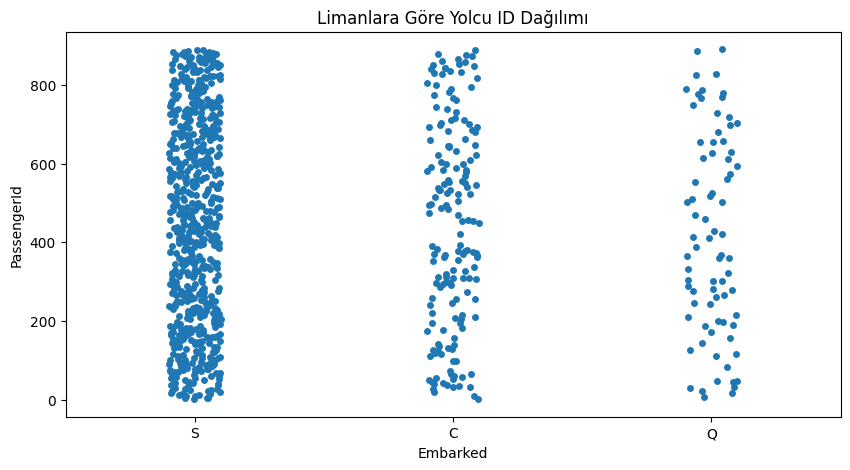

In [97]:
temp_df = df.dropna(subset=['Embarked'])

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.stripplot(x='Embarked', y='PassengerId', data=temp_df, jitter=True)
plt.title('Limanlara Göre Yolcu ID Dağılımı')
plt.show()

In [101]:
df[df["Embarked"].isnull()][["PassengerId", "Pclass", "Fare", "Sex", "Cabin"]]

,PassengerId,Pclass,Fare,Sex,Cabin
61,62,1,80.0,female,B28
829,830,1,80.0,female,B28


In [102]:
df.groupby(["Pclass", "Embarked"])["Fare"].median()

Pclass  Embarked
1       C           78.2667
        Q           90.0000
        S           52.0000
2       C           24.0000
        Q           12.3500
        S           13.5000
3       C            7.8958
        Q            7.7500
        S            8.0500
Name: Fare, dtype: float64

In [103]:
df["Embarked"] = df["Embarked"].fillna("C")